<a href="https://colab.research.google.com/github/celiabaigorri/churn-classification-project/blob/main/ProyectoParteIIIBaigorri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Introducción. ¿Cómo es el dataset?**

In [ ]:
El dataset consta de 10128 filas y más de 15 columnas. La variable objetivo es la columna "Attrition_Flag" y se pretende conocer la tendencia de las bajas de los clientes.

# **Objetivo:**

El objetivo principal de este proyecto es desarrollar un modelo de clasificación que permita identificar patrones asociados al abandono de clientes, utilizando técnicas básicas de machine learning. A través del análisis de los datos y la construcción de un modelo predictivo, se busca comprender **qué variables tienen mayor influencia en el churn** y evaluar la capacidad del modelo para predecir el comportamiento de los clientes, y así tomar decisiones empresariales para evitar la pérdida de clientes real, así como evitar los costes de un modelo mal entrenado que pueda generar falsos positivos (clientes que el modelo predice que se van cuando no es así).

Este trabajo tiene como finalidad aplicar de forma práctica conceptos fundamentales de ciencia de datos, tales como la selección de variables (feature selection), el entrenamiento de modelos de clasificación, la evaluación mediante métricas básicas y la interpretación de resultados, estableciendo una base metodológica sólida para futuros desarrollos más avanzados.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

# IMPORTANT: Replace '/content/drive/MyDrive/path/to/your/file.csv' with the actual path to your CSV file in Google Drive
# Example: If your file is directly in 'My Drive', the path might be '/content/drive/MyDrive/BankChurners.csv'
# df = pd.read_csv('/content/drive/MyDrive/path/to/your/file.csv')

# If you intend to use the BankChurners dataset from GitHub again, uncomment the line below:
url = "https://raw.githubusercontent.com/celiabaigorri/datasets-python/main/BankChurners.csv"
df = pd.read_csv(url)

df.head()

Mounted at /content/drive


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


# Limpieza, detección de NaN, transformación de datos y detección de Outliers.

In [ ]:
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [ ]:
(df == "").sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [ ]:
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


No hay datos NaN (vacíos) ni vacíos ocultos

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).sum()
outliers

,0
CLIENTNUM,0
Customer_Age,2
Dependent_count,0
Months_on_book,386
Total_Relationship_Count,0
Months_Inactive_12_mon,331
Contacts_Count_12_mon,629
Credit_Limit,984
Total_Revolving_Bal,0
Avg_Open_To_Buy,963


Tras la detección de valores atípicos mediante métodos estadísticos, se observa que la mayoría de las variables presentan valores extremos en cantidades significativas. Sin embargo, al analizar el contexto del dataset (datos financieros y de comportamiento de clientes), se concluye que dichos valores no representan errores de medición sino variabilidad real de la población.

En particular, variables como ingresos, montos de transacciones, límites de crédito y frecuencia de uso presentan distribuciones asimétricas con colas largas, lo cual es esperable en este tipo de datos.

En el caso de la variable edad (Customer_Age), los valores mínimos y máximos se encuentran dentro de rangos humanos lógicos (26 y 73 años), por lo que no se consideran errores ni valores inválidos.

Por tanto, no se realiza eliminación ni transformación de outliers, con el objetivo de no distorsionar la distribución original del dataset ni perder información relevante para el modelo predictivo.

Sin embargo, sí se procede a eliminar columnas que pueden distorsionar el actual modelo, pudiendo haber sido creadas en anteriores ocasiones: Naive_Bayes_Classifier_Attrition_Flag_..._1 → 1691
Naive_Bayes_Classifier_Attrition_Flag_..._2 → 1688


In [ ]:
display(numeric_df.describe())

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


In [ ]:
df = df.drop(columns=[col for col in df.columns if "Naive_Bayes_Classifier" in col])
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,0,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


EDA

In [ ]:
#analisis estadistico
df.describe()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,target
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,...,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,0.839340,46.325960,0.470919,2.346203,3.096574,1.463415,2.863928,0.179816,35.928409,...,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.160660
std,3.690378e+07,0.367235,8.016814,0.499178,1.298908,1.834812,0.737808,1.504700,0.693039,7.986416,...,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.367235
min,7.080821e+08,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,...,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000000
25%,7.130368e+08,1.000000,41.000000,0.000000,1.000000,2.000000,1.000000,2.000000,0.000000,31.000000,...,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000000
50%,7.179264e+08,1.000000,46.000000,0.000000,2.000000,3.000000,1.000000,3.000000,0.000000,36.000000,...,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000000
75%,7.731435e+08,1.000000,52.000000,1.000000,3.000000,5.000000,2.000000,4.000000,0.000000,40.000000,...,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000000
max,8.283431e+08,1.000000,73.000000,1.000000,5.000000,6.000000,3.000000,5.000000,3.000000,56.000000,...,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,1.000000


array([[<Axes: title={'center': 'CLIENTNUM'}>,
        <Axes: title={'center': 'Attrition_Flag'}>,
        <Axes: title={'center': 'Customer_Age'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Dependent_count'}>],
       [<Axes: title={'center': 'Education_Level'}>,
        <Axes: title={'center': 'Marital_Status'}>,
        <Axes: title={'center': 'Income_Category'}>,
        <Axes: title={'center': 'Card_Category'}>,
        <Axes: title={'center': 'Months_on_book'}>],
       [<Axes: title={'center': 'Total_Relationship_Count'}>,
        <Axes: title={'center': 'Months_Inactive_12_mon'}>,
        <Axes: title={'center': 'Contacts_Count_12_mon'}>,
        <Axes: title={'center': 'Credit_Limit'}>,
        <Axes: title={'center': 'Total_Revolving_Bal'}>],
       [<Axes: title={'center': 'Avg_Open_To_Buy'}>,
        <Axes: title={'center': 'Total_Amt_Chng_Q4_Q1'}>,
        <Axes: title={'center': 'Total_Trans_Amt'}>,
        <Axes: title={'center': 'Total

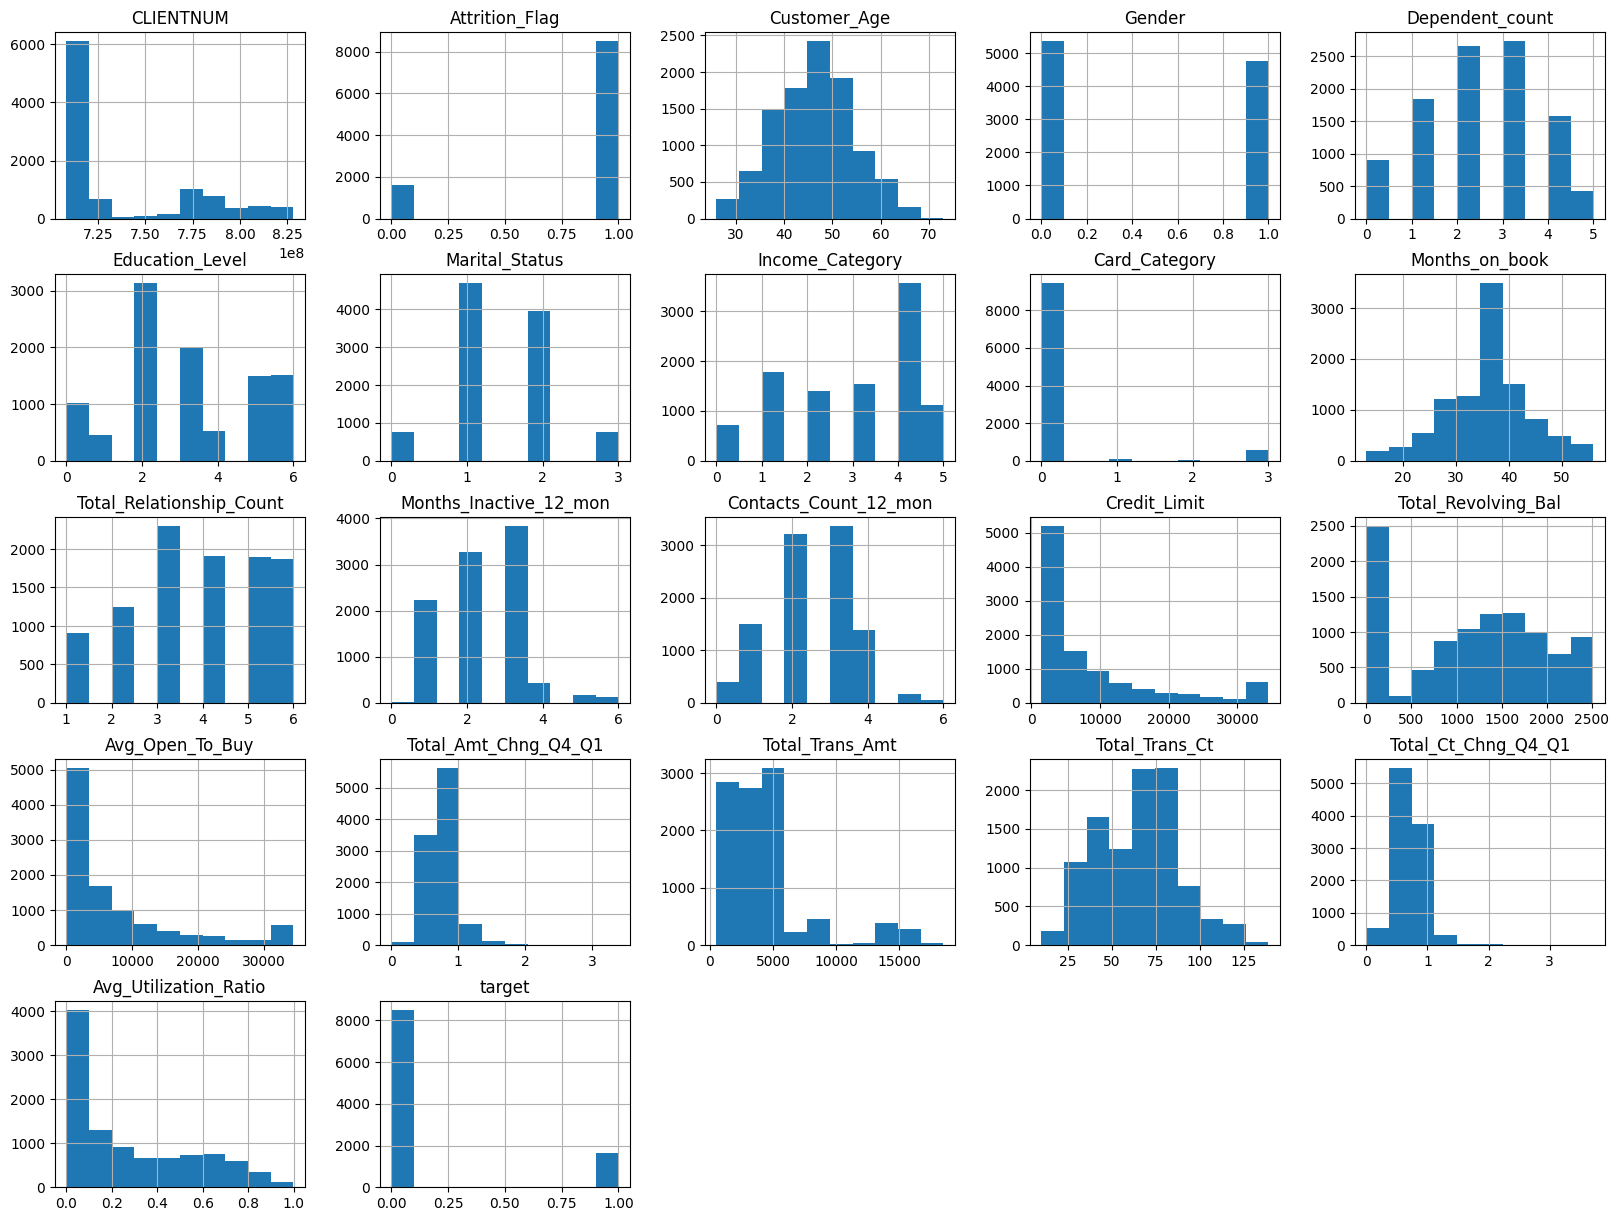

In [ ]:
#analisis univariado
df.describe()
df.hist(figsize=(20,15))

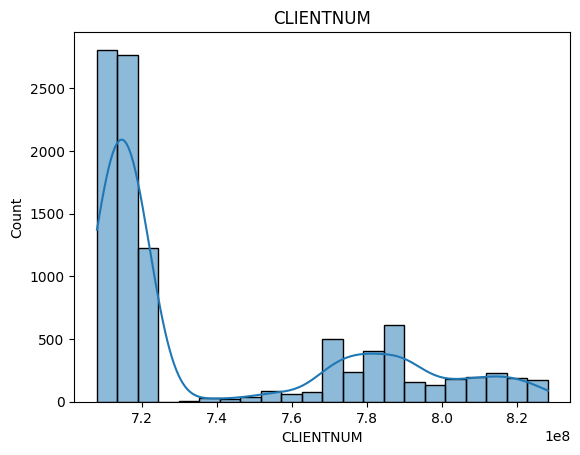

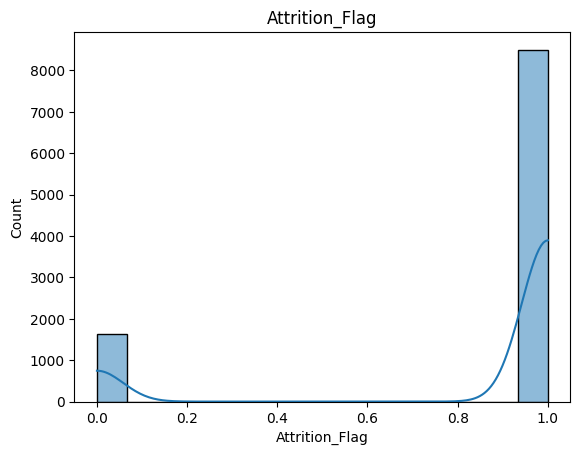

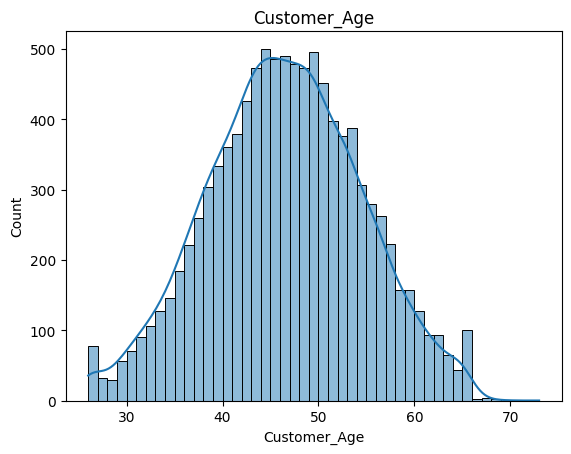

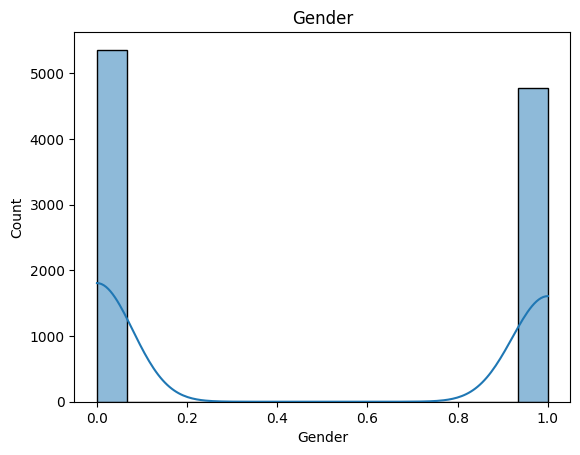

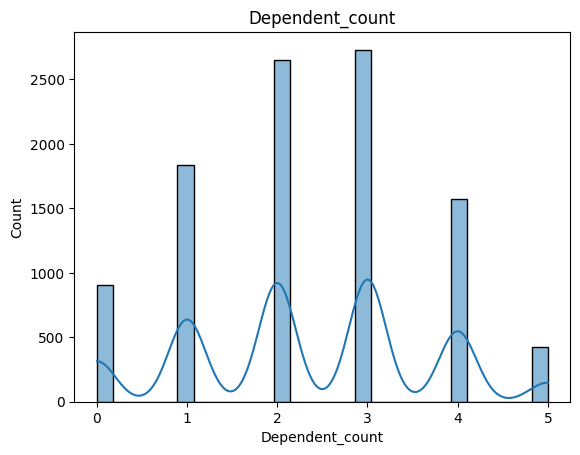

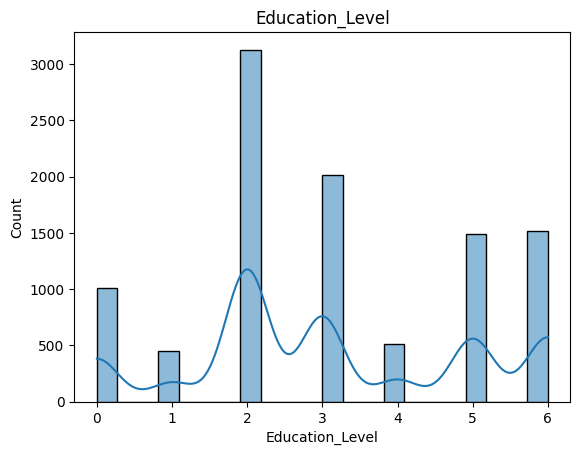

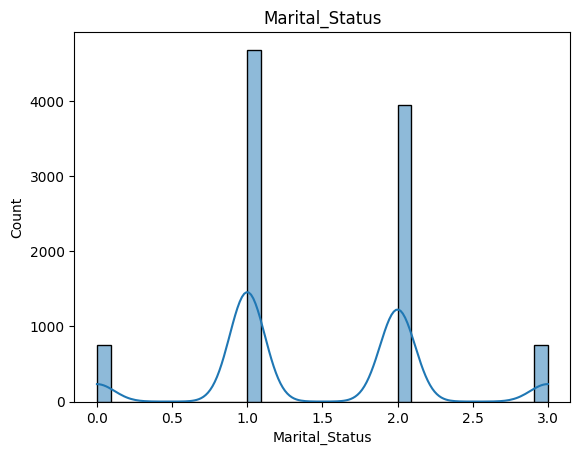

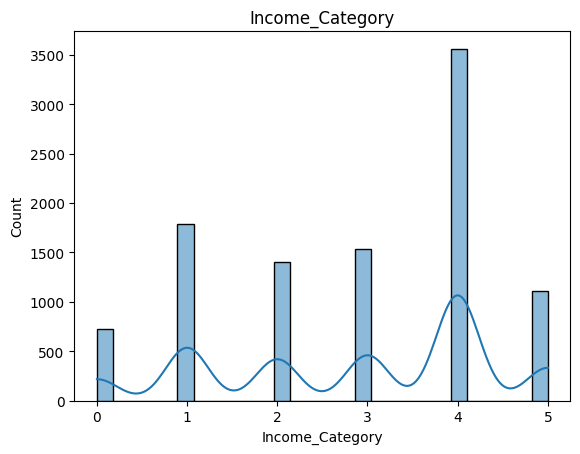

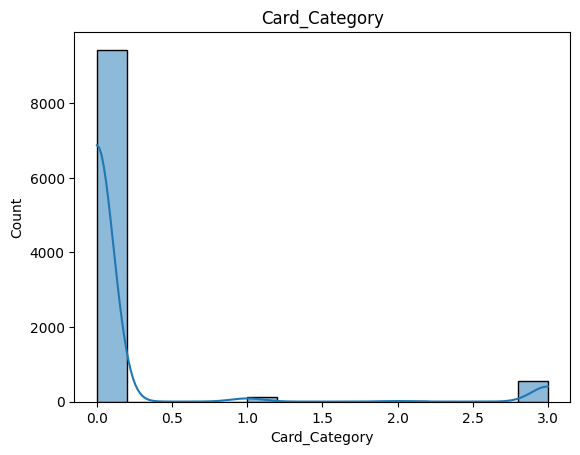

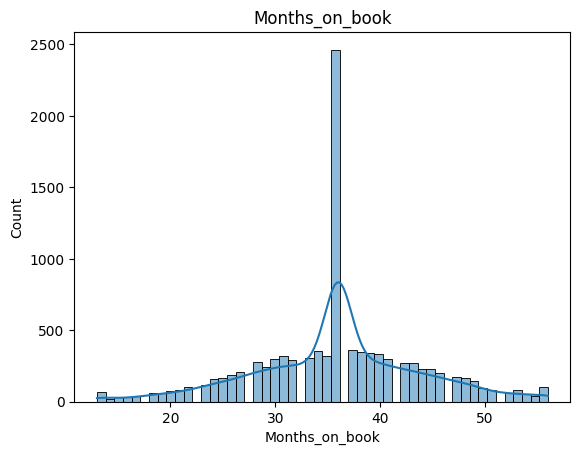

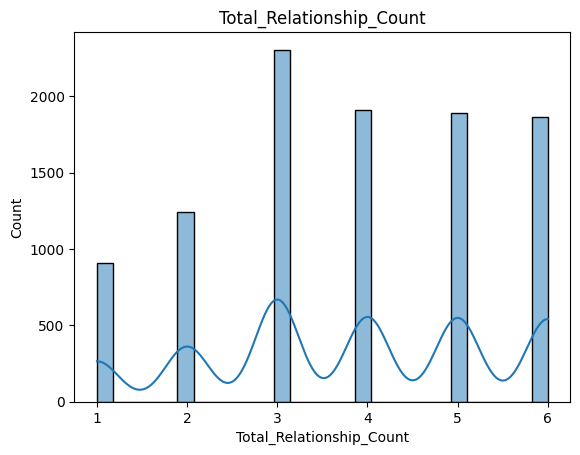

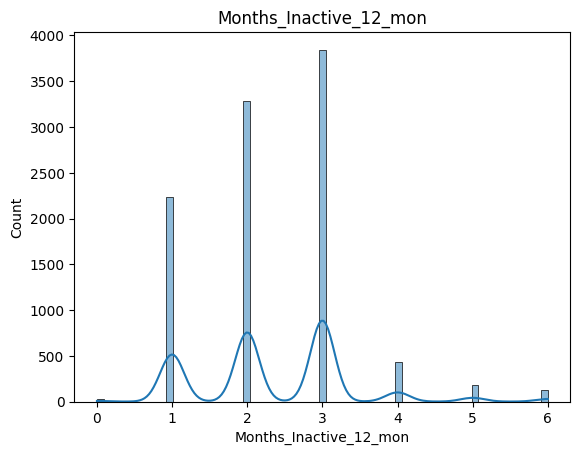

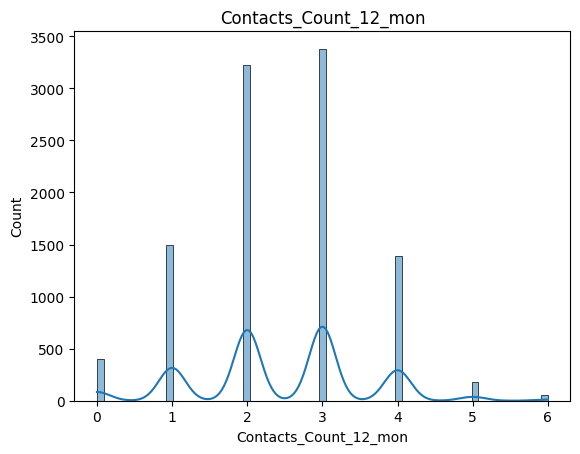

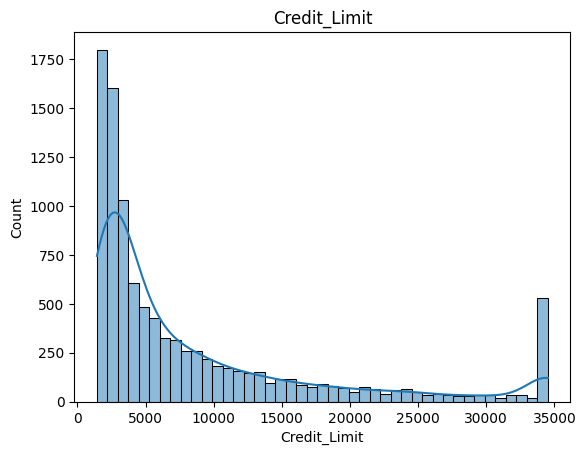

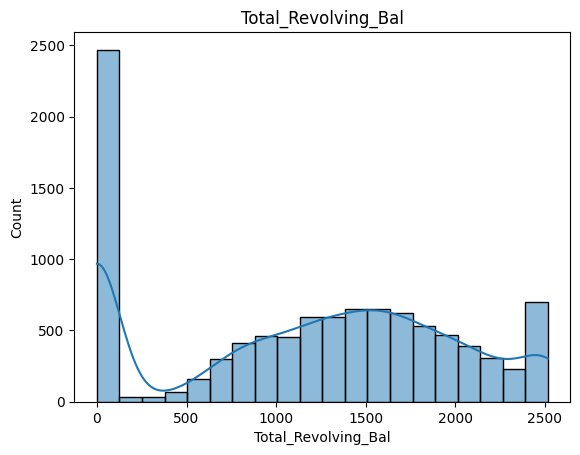

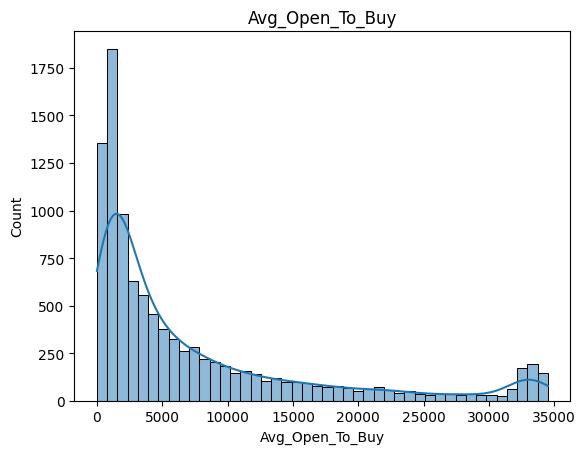

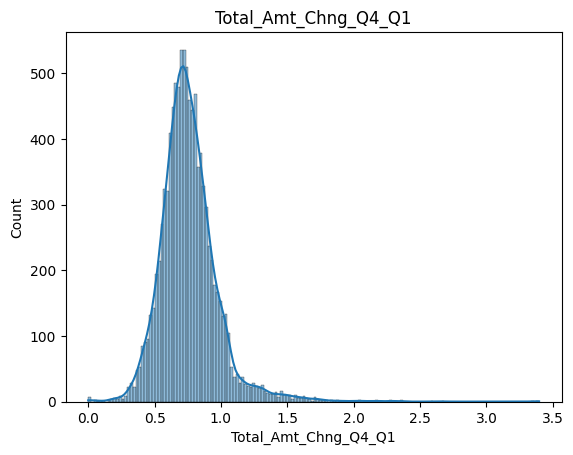

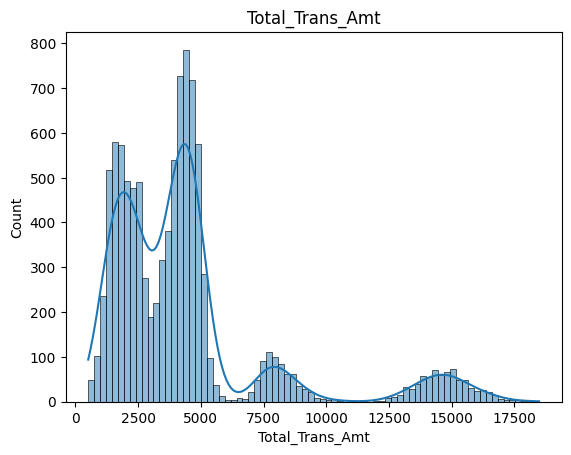

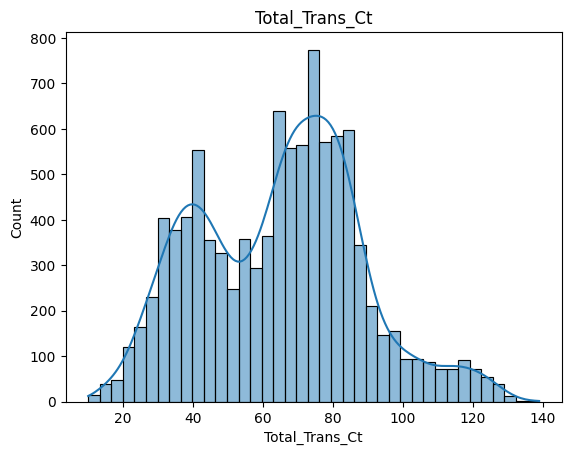

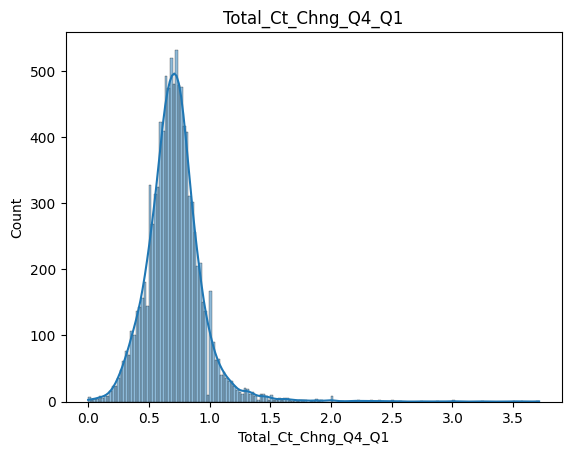

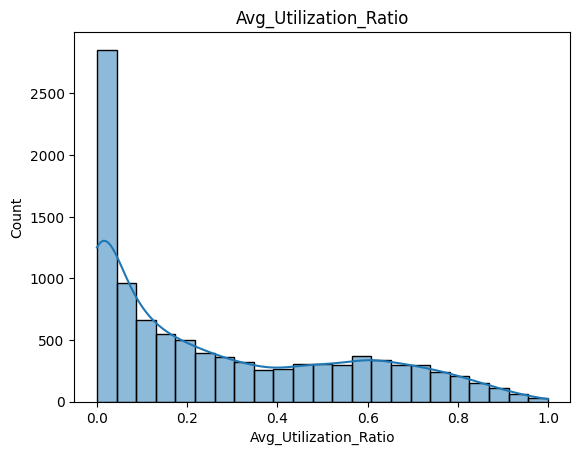

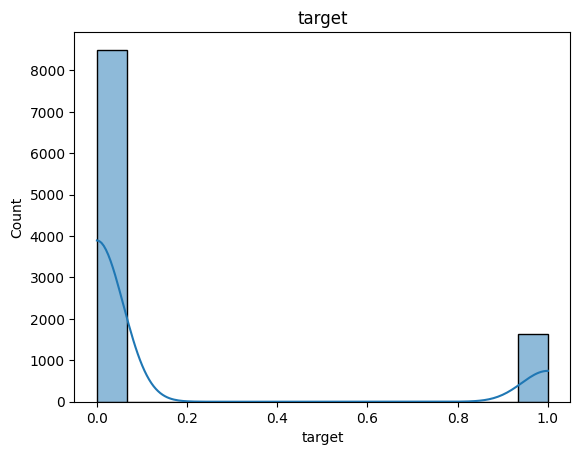

In [ ]:
#distribuciones
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.select_dtypes(include='number').columns:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

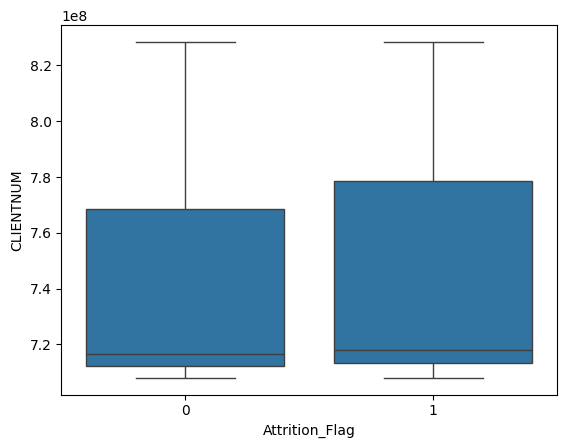

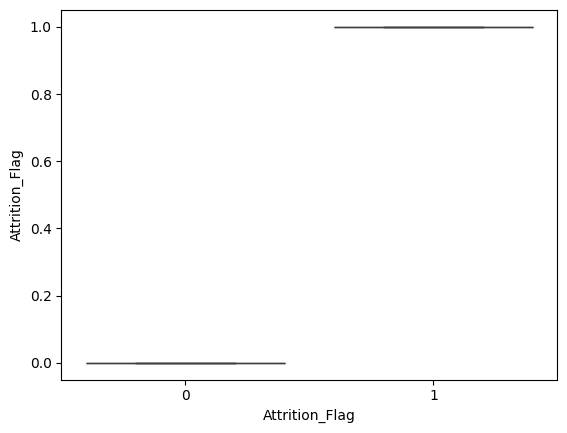

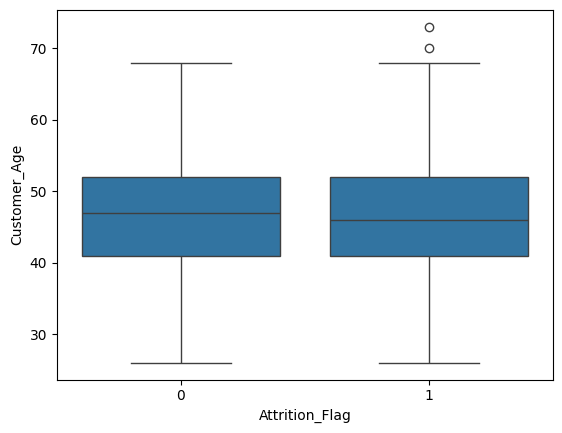

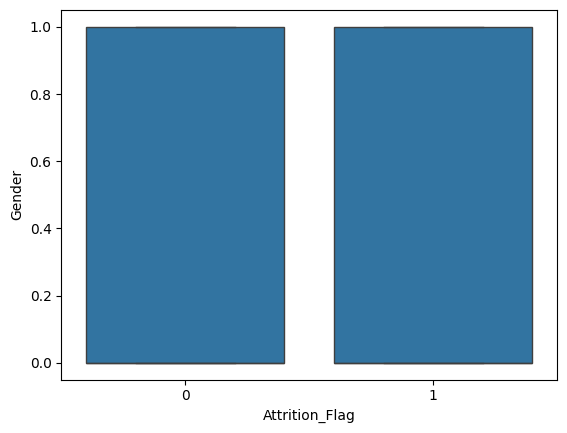

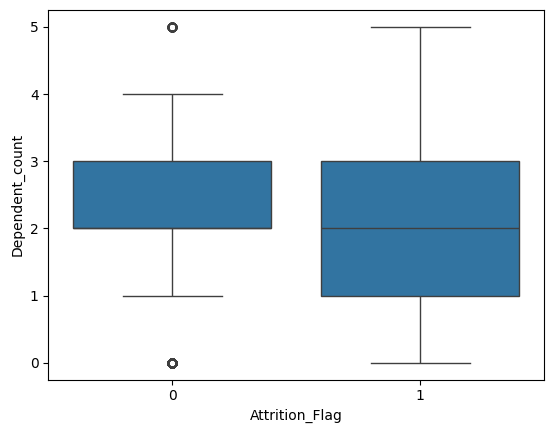

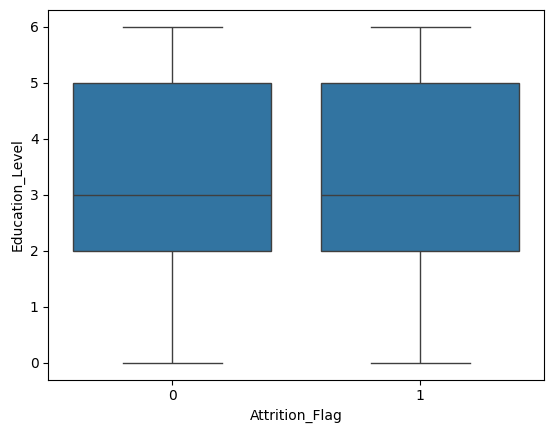

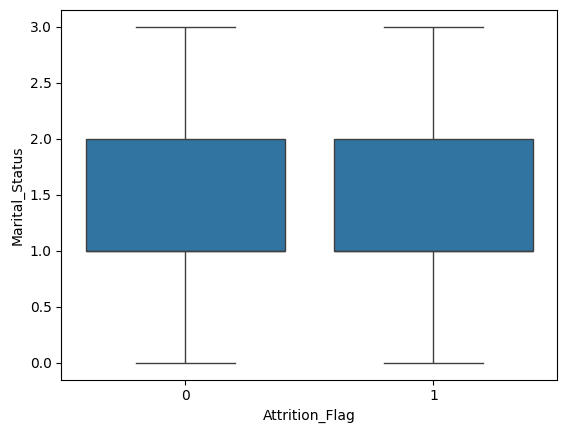

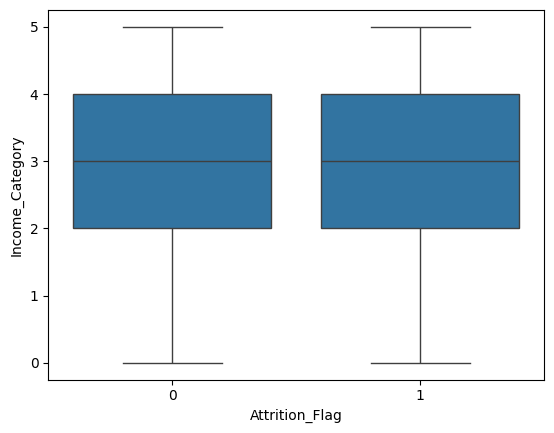

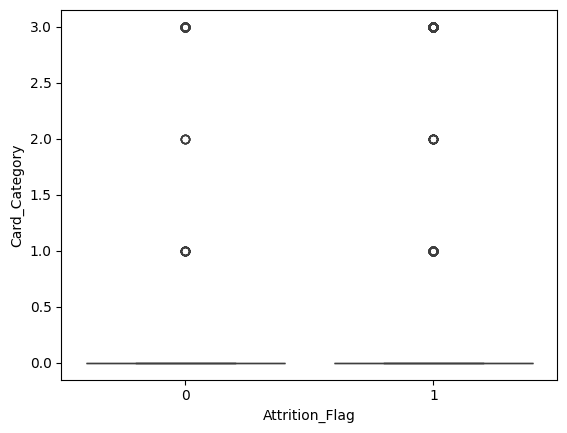

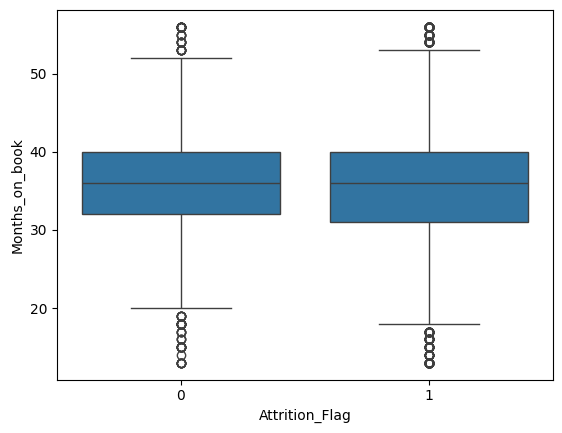

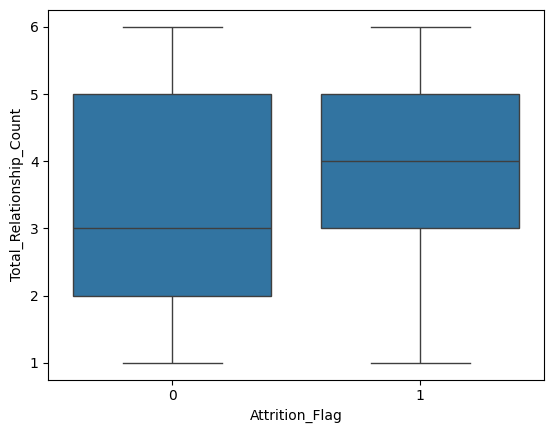

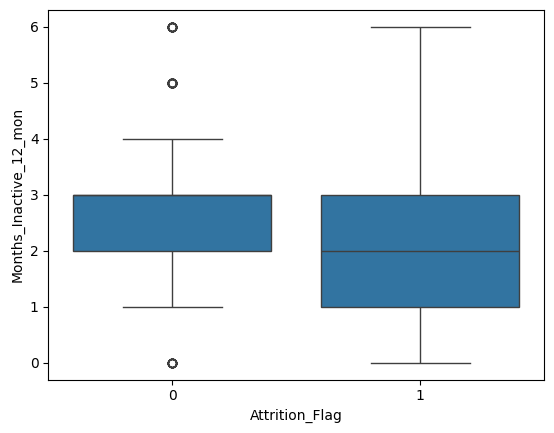

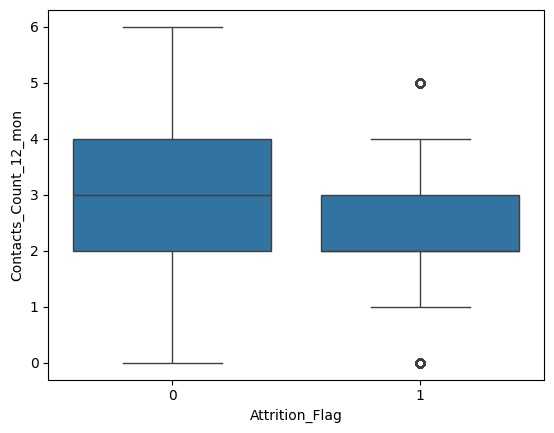

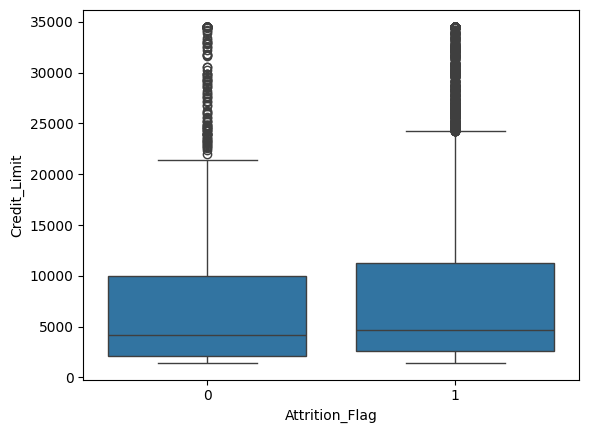

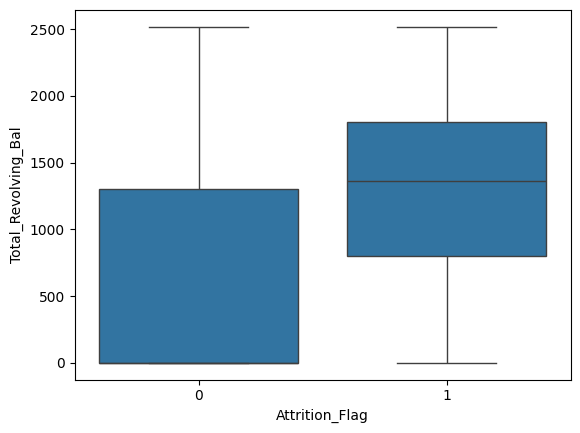

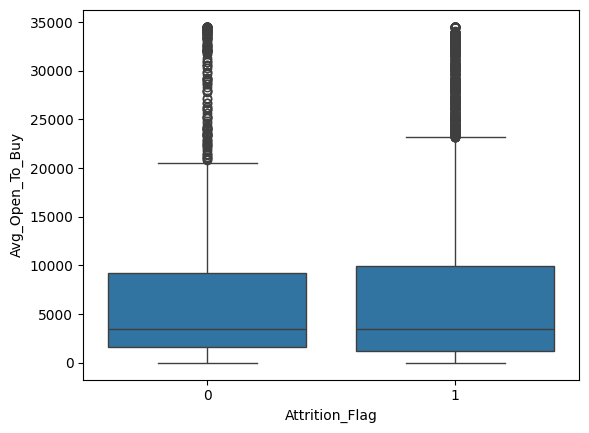

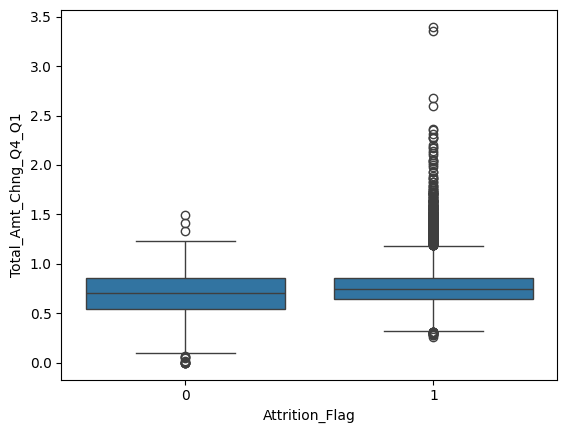

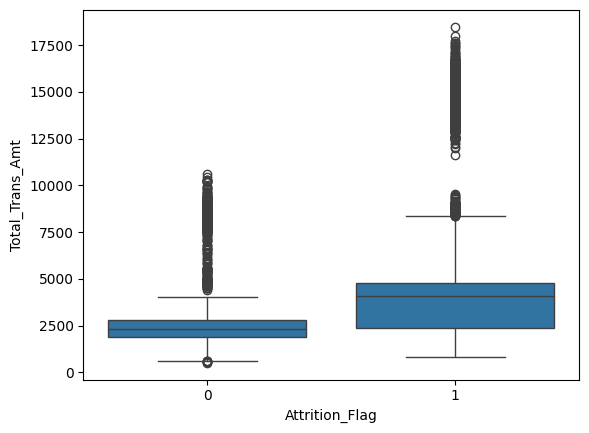

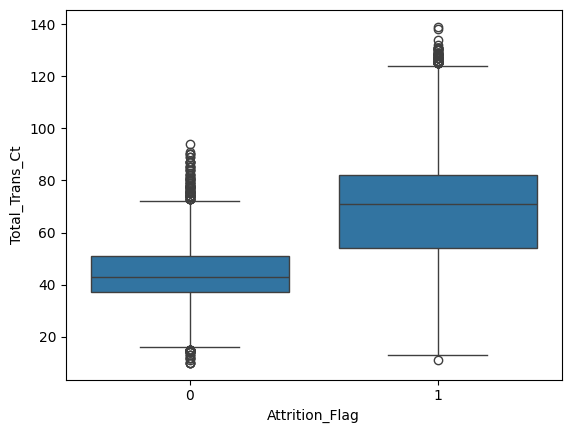

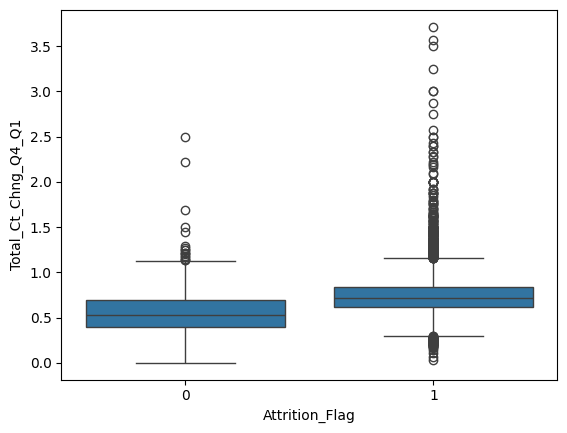

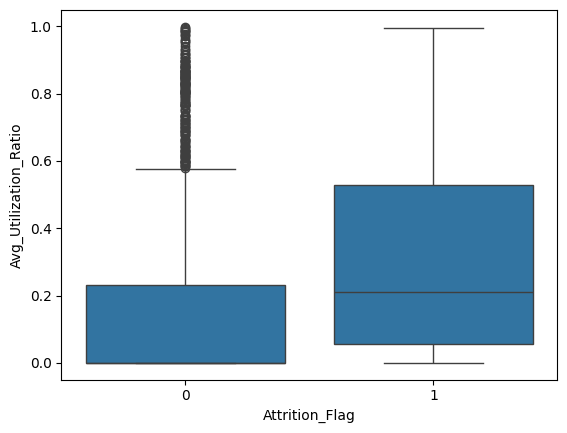

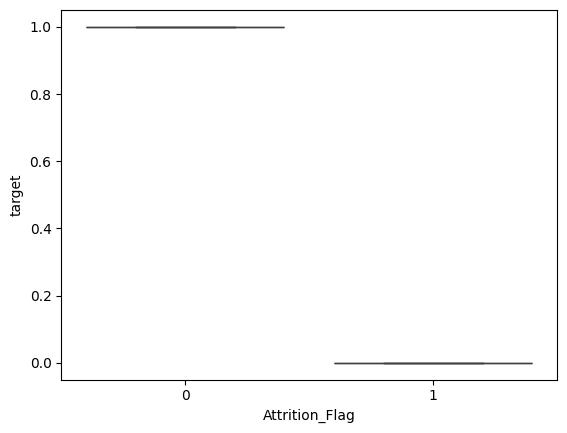

In [ ]:
#variable objetivo vs resto (bivariado)
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(x=df['Attrition_Flag'], y=df[col])
    plt.show()

<Axes: >

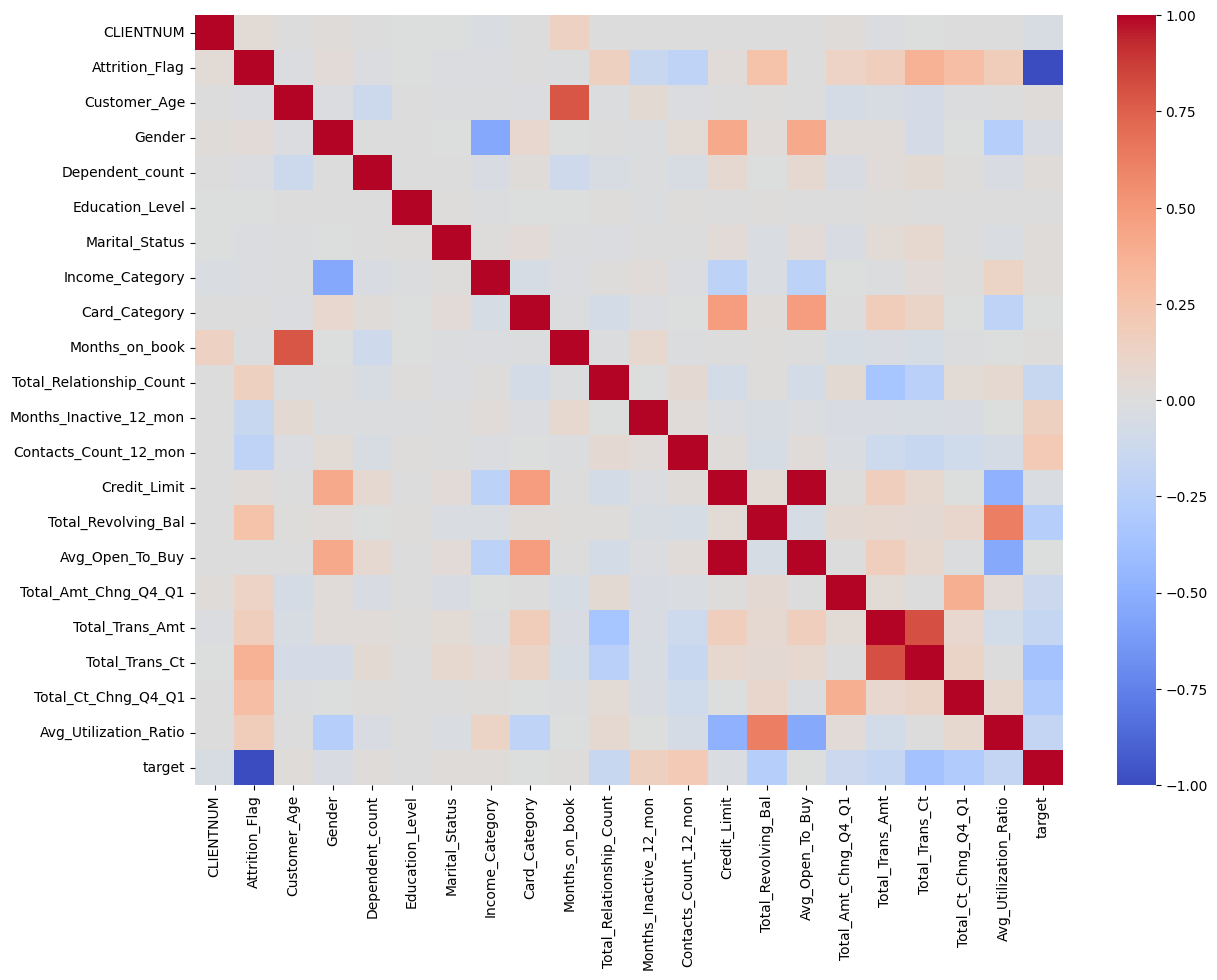

In [ ]:
#correlaciones
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)

In [ ]:
#correlaciones
for col in df.select_dtypes(include='object').columns:
    print(df[col].value_counts())

# TRANSFORMACIÓN DE DATOS

In [ ]:
# variable objetivo: Attrition Flag (Clientes activos o no)
# After Label Encoding, 'Existing Customer' is likely 1 and 'Attrited Customer' is 0.
# To align with desired target (1 for Attrited, 0 for Existing), we invert.
df['target'] = 1 - df['Attrition_Flag']

Codificación de categorías:


In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='object').columns

encoder = LabelEncoder()
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

Feature selection: reducción de dimensionalidad. Metodo SelectKBest

In [ ]:
X = df.drop(['target'], axis=1)
y = df['target']

selector = SelectKBest(score_func=chi2, k=10)
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
selected_features

Index(['CLIENTNUM', 'Attrition_Flag', 'Total_Relationship_Count',
       'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
       'Total_Revolving_Bal', 'Total_Trans_Amt', 'Total_Trans_Ct',
       'Avg_Utilization_Ratio'],
      dtype='object')

In [ ]:
#revelar NaN en variable y
df['Attrition_Flag'].value_counts(dropna=False)

,count
Attrition_Flag,
1,8500
0,1627


Ha debido de haber una mala codificacion de la variable y en la conversiñon previa, el modelo ha podido crear NaN a partir de fallos en la lectura de datos (espacios, irregularidades, etc.). Por ello, se va a tratar a continuación de normalizar el texto para recuperar esos datos y mapear correctamente.

In [ ]:
#normalización del texto
df['Attrition_Flag'] = df['Attrition_Flag'].astype(str).str.strip().str.lower()

In [ ]:
#mapear correctamente
mapping = {
    'existing customer': 0,
    'attrited customer': 1
}

df['Attrition_Flag'] = df['Attrition_Flag'].map(mapping)

In [ ]:
#verificación:
df['Attrition_Flag'].isnull().sum()

np.int64(10127)

In [ ]:
df['Attrition_Flag'].value_counts(dropna=False)

,count
Attrition_Flag,
NaN,10127


In [ ]:
#Se procede a recargar el dataset porque tras la acción de "map"
#ya no es reversible
#el dato a string y siguen saliendo NaN
df = pd.read_csv(url)

In [ ]:
#Cuenta los valores reales y NaN
df['Attrition_Flag'].value_counts(dropna=False)

,count
Attrition_Flag,
Existing Customer,8500
Attrited Customer,1627


In [ ]:
#Normalización de texto
df['Attrition_Flag'] = df['Attrition_Flag'].astype(str).str.strip().str.lower()

In [ ]:
#mapear
mapping = {
    'existing customer': 0,
    'attrited customer': 1
}

df['Attrition_Flag'] = df['Attrition_Flag'].map(mapping)

In [ ]:
#verificar
df['Attrition_Flag'].isnull().sum()

np.int64(0)

Ahora sí se han convertido correctamente todos los valores de "Attrition Flag" a 0 y 1.

De nuevo, se vuelve a aplicar SelectKBest para reducción de la dimensionalidad

In [ ]:
X = df.drop(['target'], axis=1)
y = df['target']

selector = SelectKBest(score_func=chi2, k=10)
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
selected_features

Index(['CLIENTNUM', 'Attrition_Flag', 'Total_Relationship_Count',
       'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
       'Total_Revolving_Bal', 'Total_Trans_Amt', 'Total_Trans_Ct',
       'Avg_Utilization_Ratio'],
      dtype='object')

In [ ]:
#Preparación de datos
# Ensure 'Attrition_Flag' is not included in the features X
features_to_use = [f for f in selected_features if f != 'Attrition_Flag']
X = df[features_to_use]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
#Modelo de clasificación RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#Metricas basicas: accuracy, matriz de confusión
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9489963803882856

Confusion Matrix:
 [[ 393  103]
 [  52 2491]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.84       496
           1       0.96      0.98      0.97      2543

    accuracy                           0.95      3039
   macro avg       0.92      0.89      0.90      3039
weighted avg       0.95      0.95      0.95      3039



In [ ]:
import pandas as pd
import numpy as np

def detectar_fugas(df_input, target_col='Attrition_Flag', corr_threshold=0.9, unique_threshold=1):
    sospechosas = []

    # Crear una copia para evitar modificar el DataFrame original
    df_temp = df_input.copy()

    # --- 1️⃣ Columnas numéricas (incluyendo las que eran categóricas y ahora son numéricas) ---
    # Obtener todas las columnas numéricas
    num_cols = df_temp.select_dtypes(include=[np.number]).columns.tolist()

    # Asegurarse de que la columna objetivo no sea tratada como una característica
    if target_col in num_cols:
        num_cols.remove(target_col)

    # Verificar si la columna objetivo es numérica para calcular correlaciones
    if pd.api.types.is_numeric_dtype(df_temp[target_col]):
        if num_cols: # Solo proceder si hay columnas numéricas para verificar
            # Calcular la correlación de las características con la columna objetivo
            corr_with_target = df_temp[num_cols + [target_col]].corr()[target_col].drop(target_col, errors='ignore').sort_values(ascending=False)

            print("=== Correlaciones con el target ===")
            for col, value in corr_with_target.items():
                if abs(value) >= corr_threshold:
                    print(f"Variable numérica sospechosa: {col}, correlación: {value:.2f}")
                    if col not in sospechosas:
                        sospechosas.append(col)
        else:
            print("No hay columnas numéricas para calcular correlaciones (excluyendo el target).")
    else:
        print(f"La columna objetivo '{target_col}' no es numérica. No se calcularán correlaciones numéricas.")


    # --- 2️⃣ Columnas con poca variabilidad por clase de target (potencial leakage) ---
    # Esto busca características que, para cada clase del target, tienen muy pocos valores únicos.
    # Por ejemplo, si cuando target=0, una columna siempre es 'A', y cuando target=1, siempre es 'B'.

    # Considerar todas las columnas excepto el target mismo
    all_features = [col for col in df_temp.columns if col != target_col]

    print(f"\n=== Columnas (posiblemente categóricas o numéricas) con poca variabilidad por clase de '{target_col}' ===")
    for col in all_features:
        if col in df_temp.columns: # Asegurarse de que la columna existe
            try:
                unique_per_class = df_temp.groupby(target_col)[col].nunique()
                # Si para *alguna* clase del target, el número de valores únicos en 'col' es <= unique_threshold
                if (unique_per_class <= unique_threshold).any():
                    print(f"Variable sospechosa por poca variabilidad por clase: {col}")
                    print(unique_per_class)
                    if col not in sospechosas:
                        sospechosas.append(col)
            except KeyError:
                print(f"No se pudo procesar la columna '{col}' para la variabilidad por clase (problema de clave). Debería ser numérica/categórica.")
            except TypeError:
                print(f"La columna '{col}' tiene un tipo incompatible para groupby().nunique().")

    if not sospechosas:
        print("\nNo se detectaron columnas sospechosas de fuga de información.")
    else:
        # Asegurarse de que la columna objetivo no se añada a la lista de sospechosas
        if target_col in sospechosas:
            sospechosas.remove(target_col)

    return sospechosas

# Uso: Ahora usamos 'target' como la columna objetivo para detectar fugas
sospechosas = detectar_fugas(df, target_col='target', corr_threshold=0.9)
print("\nColumnas a revisar/eliminar antes de entrenar:", sospechosas)


=== Correlaciones con el target ===
Variable numérica sospechosa: Attrition_Flag, correlación: -1.00

=== Columnas (posiblemente categóricas o numéricas) con poca variabilidad por clase de 'target' ===
Variable sospechosa por poca variabilidad por clase: Attrition_Flag
target
0    1
1    1
Name: Attrition_Flag, dtype: int64

Columnas a revisar/eliminar antes de entrenar: ['Attrition_Flag']


Conclusión: hay overfitting.
Voy a revisar si estan separados los datos X e Y (Trains/test split) o que no haya fuga de datos de la variable objeto

In [ ]:
#Verificar separación de datos
from sklearn.model_selection import train_test_split

X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Fuga de datos de var. objetivo. Correlación con var. obj.:
import pandas as pd

correlation = df.corr()['Attrition_Flag'].sort_values(ascending=False)
print(correlation)

Attrition_Flag              1.000000
Contacts_Count_12_mon       0.204491
Months_Inactive_12_mon      0.152449
Dependent_count             0.018991
Marital_Status              0.018597
Customer_Age                0.018203
Income_Category             0.017584
Months_on_book              0.013687
Education_Level             0.005551
Avg_Open_To_Buy            -0.000285
Card_Category              -0.006038
Credit_Limit               -0.023873
Gender                     -0.037272
CLIENTNUM                  -0.046430
Total_Amt_Chng_Q4_Q1       -0.131063
Total_Relationship_Count   -0.150005
Total_Trans_Amt            -0.168598
Avg_Utilization_Ratio      -0.178410
Total_Revolving_Bal        -0.263053
Total_Ct_Chng_Q4_Q1        -0.290054
Total_Trans_Ct             -0.371403
target                     -1.000000
Name: Attrition_Flag, dtype: float64


In [ ]:
for col in df.columns:
    if col != 'Attrition_Flag':
        print(f"\nColumna: {col}")
        print(df.groupby('Attrition_Flag')[col].nunique())


Columna: CLIENTNUM
Attrition_Flag
0    8500
1    1627
Name: CLIENTNUM, dtype: int64

Columna: Customer_Age
Attrition_Flag
0    45
1    42
Name: Customer_Age, dtype: int64

Columna: Gender
Attrition_Flag
0    2
1    2
Name: Gender, dtype: int64

Columna: Dependent_count
Attrition_Flag
0    6
1    6
Name: Dependent_count, dtype: int64

Columna: Education_Level
Attrition_Flag
0    7
1    7
Name: Education_Level, dtype: int64

Columna: Marital_Status
Attrition_Flag
0    4
1    4
Name: Marital_Status, dtype: int64

Columna: Income_Category
Attrition_Flag
0    6
1    6
Name: Income_Category, dtype: int64

Columna: Card_Category
Attrition_Flag
0    4
1    4
Name: Card_Category, dtype: int64

Columna: Months_on_book
Attrition_Flag
0    44
1    44
Name: Months_on_book, dtype: int64

Columna: Total_Relationship_Count
Attrition_Flag
0    6
1    6
Name: Total_Relationship_Count, dtype: int64

Columna: Months_Inactive_12_mon
Attrition_Flag
0    7
1    7
Name: Months_Inactive_12_mon, dtype: int64



No hay fuga de información

In [ ]:
#Separacióntrain/test y STRATIFY para equilibrar datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#Cross-validation
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(scores)
print("Mean Accuracy:", scores.mean())

[1. 1. 1. 1. 1.]
Mean Accuracy: 1.0


Sigue saliendo 1.0 de accuracy, por lo que sigue habiendo overfitting por alguna razón.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(scores)
print("Mean Accuracy:", scores.mean())

[1. 1. 1. 1. 1.]
Mean Accuracy: 1.0


Sigue apareciendo 1.0 de accuracy, voy a comprobar qué columnas pueden estar filtrando información a la variable objetivo.


## Corregir Cross-Validation para evitar fuga de datos

Revisar y corregir la aplicación de la validación cruzada para asegurar que no haya fuga de datos de la variable objetivo, utilizando las características (`X`) y la variable objetivo (`y`) que ya han sido correctamente definidas para el entrenamiento del modelo.


 Los pasos anteriores de validación cruzada dieron como resultado una precisión de 1,0 debido a la fuga de datos. Esto se debió a que se incluyó una columna directamente correlacionada con la variable objetivo («Attrition_Flag») dentro de las características (X) utilizadas para la validación cruzada, mientras que el objetivo (y) también era «Attrition_Flag». Para corregir esto, redefiniré X para excluir «Attrition_Flag» y utilizaré «target» como la verdadera variable objetivo y.

In [ ]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier



X = df[features_to_use] # Using features_to_use from prior steps
y = df['Attrition_Flag']

# Perform cross-validation
model = RandomForestClassifier(random_state=42)
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross-validation scores: [0.85044423 0.90523198 0.95703704 0.96345679 0.84592593]
Mean Accuracy: 0.9044191924731576


In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9489963803882856

Confusion Matrix:
 [[ 393  103]
 [  52 2491]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.79      0.84       496
           1       0.96      0.98      0.97      2543

    accuracy                           0.95      3039
   macro avg       0.92      0.89      0.90      3039
weighted avg       0.95      0.95      0.95      3039



Conclusiones:

1. Finalmente se consiguió obtener un 90% de accuracy para el modelo tras definir correctamente la variable objetivo Y. Es un resultado mucho más realista.
2. Hay 103 falsos positivos y 52 falsos negativos, lo cual son unas métricas realistas y con bastante acierto.
3. La clase 0 (Attrited costumer) tiene una precisión del 0.88, es decir, el 88% efectivamente lo eran. La clase 1 (Existing costumer), un 96% de acierto.
4. El recall de Attrited Costumer tuvo un 79% de aciertos positivos y un 98% de aciertos de los que efectivamente eran Existing costumer. Es una ratio alta, lo que indica que el modelo es bueno para localizar los casos positivos existentes y guarda relación con los datos de precisión, aunque es más baja que la precisión.
5. Hay un F1- score para ambas clases (0.84 y 0.97) lo que indica que el modelo tiene buena precisión y recall.
6. Hay un soporte de 496 Attrited Costumers y 2543 de Existing costumers.

El modelo es muy bueno predicioend a "Existing costumer". En cuanto a "Attrited Costumer", la precisión es buena (88%), pero el recal (79%) es un poco más bajo, lo que significa que el modelo pierde a un 21% de clientes que SÍ abandonaron. Dependiendo de los costos asociados a los falsos negativos (no identificar a un cliente que abandona) o falsos positivos (predecir que alguien abandona cuando no lo hará), podrías querer ajustar el modelo o probar otras técnicas para mejorar el recall de la Clase 0.